n = 4000
--------------------------------------------------
k = 0.5  | Largest Component Fraction = 0.0037
k = 0.8  | Largest Component Fraction = 0.0146
k = 1    | Largest Component Fraction = 0.1031
k = 1.2  | Largest Component Fraction = 0.3173
k = 1.5  | Largest Component Fraction = 0.5773
k = 2    | Largest Component Fraction = 0.7992
k = 3    | Largest Component Fraction = 0.9422


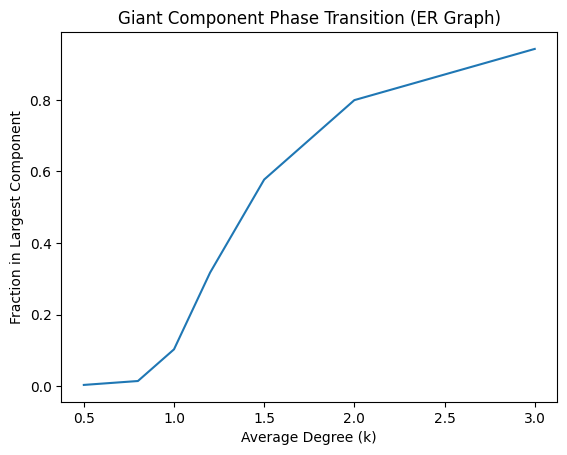

In [2]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

n = 4000
k_values = [0.5, 0.8, 1, 1.2, 1.5, 2, 3]
trials = 3 

largest_fraction = []

print("n =", n)
print("--------------------------------------------------")

for k in k_values:
    fractions = []
    p = k / (n - 1)
    
    for _ in range(trials):
        G = nx.erdos_renyi_graph(n, p)
        
        if len(G) > 0:
            largest_cc = max(nx.connected_components(G), key=len)
            fraction = len(largest_cc) / n
            fractions.append(fraction)
    
    avg_fraction = np.mean(fractions)
    largest_fraction.append(avg_fraction)
    
    print(f"k = {k:<4} | Largest Component Fraction = {avg_fraction:.4f}")

plt.figure()
plt.plot(k_values, largest_fraction)
plt.xlabel("Average Degree (k)")
plt.ylabel("Fraction in Largest Component")
plt.title("Giant Component Phase Transition (ER Graph)")
plt.show()
